1. EDA

Inicialmente, dado que se conocía el tipo de datos (gracias al contexto del problema en el PDF brindado), se buscó información sobre este datase. En el proceso, se identificó que esta información proviene del international coffee organization (https://ico.org/)

Con base en un dataset obtenido desde kaggle (https://www.kaggle.com/datasets/michals22/coffee-dataset), se realizóo la comparación entre los datasets:

In [ ]:
#%pip install pandas
#%pip install pyarrow

In [22]:
from pathlib import Path

import pandas as pd
import pyarrow.parquet as pq

data_dir = Path("C:/Users/Angie Daniela Garcia/Documents/prueba_nttdata/data/")

path_parquet_coffee_db = data_dir / 'coffee_db.parquet'
path_parquet_coffee_db_original = data_dir / 'coffee_db_original.csv'

parquet_coffee_db = pd.read_parquet(path_parquet_coffee_db, engine='pyarrow')
parquet_coffee_db_original = pd.read_csv(path_parquet_coffee_db_original)

print(parquet_coffee_db.head())
print("------------")
print(parquet_coffee_db_original.head())

                            Country      Coffee type    1990/91    1991/92  \
0                            Angola  Robusta/Arabica    1200000    1800000   
1  Bolivia (Plurinational State of)          Arabica    1500000    1620000   
2                            Brazil  Arabica/Robusta  492000000  510000000   
3                           Burundi  Arabica/Robusta     120000      96000   
4                           Ecuador  Arabica/Robusta   21000000   21000000   

     1992/93    1993/94    1994/95    1995/96    1996/97    1997/98  ...  \
0    2100000    1200000    1500000     600000    1200000    2400000  ...   
1    1650000    1710000    1770000    1830000    1890000    1950000  ...   
2  534000000  546000000  558000000  606000000  660000000  690000000  ...   
3     102000     114600     120000     120000     120000     120000  ...   
4   21000000   21000000   21000000   21000000   18000000   18000000  ...   

      2011/12     2012/13     2013/14     2014/15     2015/16     2016/17 

In [23]:
print(f'Estructura: {parquet_coffee_db.shape}')
print(f'Tamaño: {parquet_coffee_db.shape}')

parquet_coffee_db.info()

Estructura: (55, 33)
Tamaño: (55, 33)
<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Country                     55 non-null     str  
 1   Coffee type                 55 non-null     str  
 2   1990/91                     55 non-null     int64
 3   1991/92                     55 non-null     int64
 4   1992/93                     55 non-null     int64
 5   1993/94                     55 non-null     int64
 6   1994/95                     55 non-null     int64
 7   1995/96                     55 non-null     int64
 8   1996/97                     55 non-null     int64
 9   1997/98                     55 non-null     int64
 10  1998/99                     55 non-null     int64
 11  1999/00                     55 non-null     int64
 12  2000/01                     55 non-null     int64
 13  2001/02                     55 non-null 

In [25]:
print(f'Estructura: {parquet_coffee_db_original.shape}')
print(f'Tamaño: {parquet_coffee_db_original.shape}')

parquet_coffee_db_original.info()

Estructura: (55, 33)
Tamaño: (55, 33)
<class 'pandas.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Country                     55 non-null     str  
 1   Coffee type                 55 non-null     str  
 2   1990/91                     55 non-null     int64
 3   1991/92                     55 non-null     int64
 4   1992/93                     55 non-null     int64
 5   1993/94                     55 non-null     int64
 6   1994/95                     55 non-null     int64
 7   1995/96                     55 non-null     int64
 8   1996/97                     55 non-null     int64
 9   1997/98                     55 non-null     int64
 10  1998/99                     55 non-null     int64
 11  1999/00                     55 non-null     int64
 12  2000/01                     55 non-null     int64
 13  2001/02                     55 non-null 

En este punto, se genera una pregunta evidente: ¿Es este el mismo dataset? Ya que vemos el mismo nùmero de datos, aparentemente el mismo nombre de columnas, y observando superficialmente, los mismos datos

Para averiguarlo, se unen ambos dataframes, y comparamos las diferencias

                             Country Coffee type  Total_domestic_consumption
2                             Brazil       Mixto                 27824700000
5                          Indonesia       Mixto                  4920480000
29                          Ethiopia     Arabica                  4536540000
41                            Mexico       Mixto                  3189660000
23                          Colombia     Arabica                  2536776384
52                         Venezuela     Arabica                  2386067999
6                         Madagascar     Robusta                   588705960
25                     Côte d'Ivoire     Robusta                   410260140
39  Lao People's Democratic Republic     Robusta                   157980000


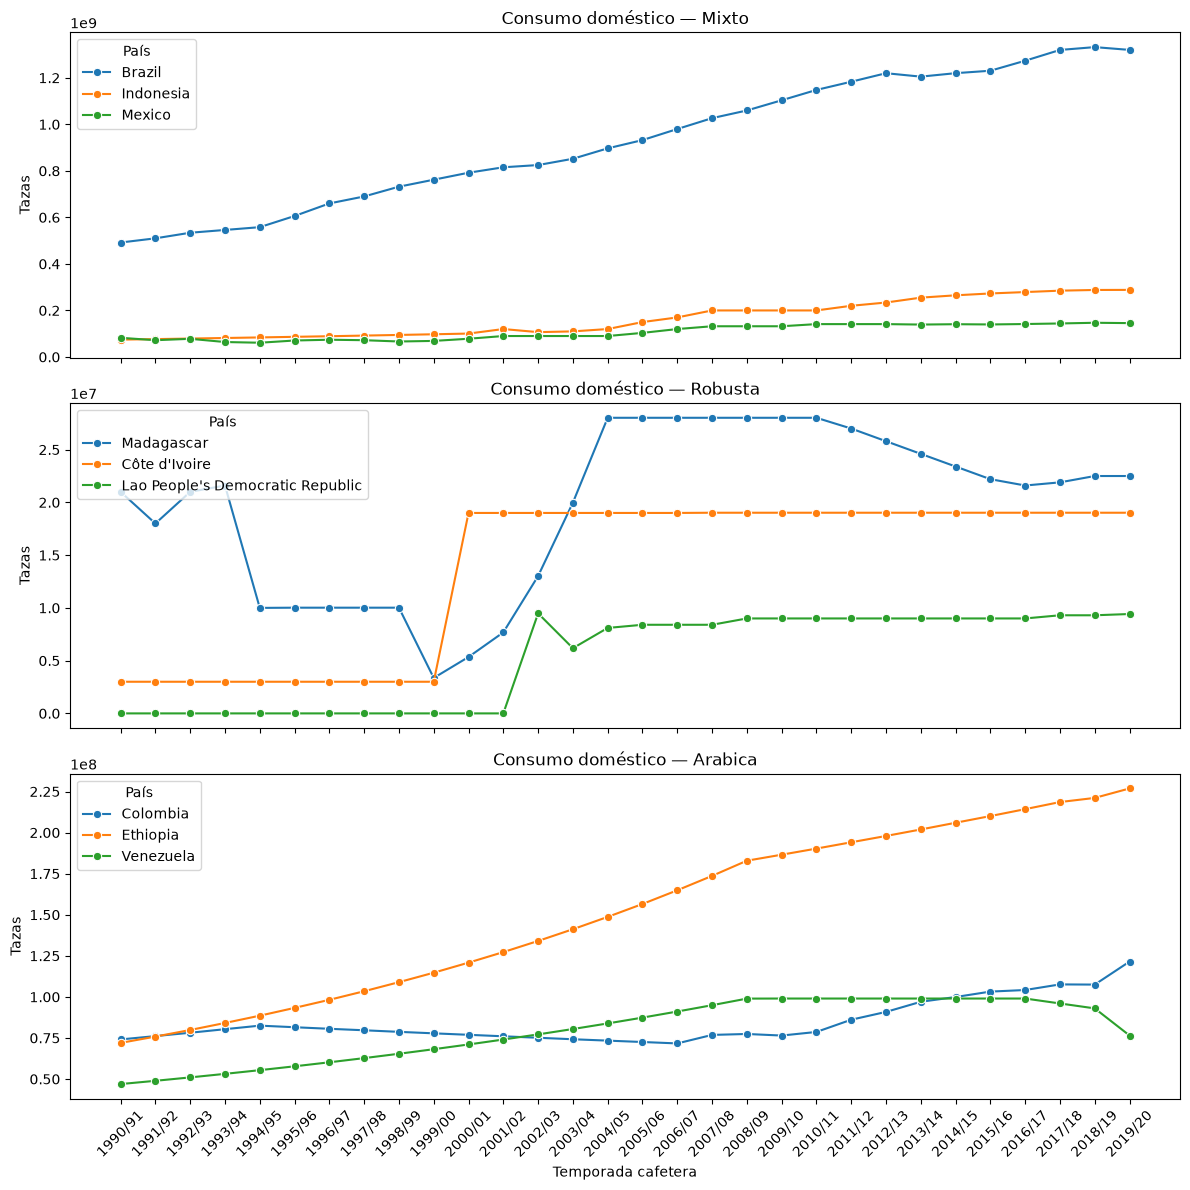

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet('C:/Users/Angie Daniela Garcia/Documents/prueba_nttdata/data/coffee_db.parquet')

# --- Paso opcional: consolidar categorías mixtas ---
# Si prefieres 3 grupos limpios (Arabica, Robusta, Mixto), descomenta:
df['Coffee type'] = df['Coffee type'].replace(
    {'Robusta/Arabica': 'Mixto', 'Arabica/Robusta': 'Mixto'}
)

# --- 1. Top 3 países por tipo de café, según consumo total ---
top3_por_tipo = (
    df.sort_values('Total_domestic_consumption', ascending=False)
      .groupby('Coffee type')
      .head(3)
)

paises_seleccionados = top3_por_tipo['Country'].tolist()
print(top3_por_tipo[['Country', 'Coffee type', 'Total_domestic_consumption']])

# --- 2. Filtrar el dataset original a esos países ---
df_filtrado = df[df['Country'].isin(paises_seleccionados)]

# --- 3. Melt a formato largo, conservando Country y Coffee type ---
columnas_anio = [c for c in df.columns if '/' in c]  # detecta las columnas tipo "1990/91"

datos_largos = df_filtrado.melt(
    id_vars=['Country', 'Coffee type'],
    value_vars=columnas_anio,
    var_name='Fecha',
    value_name='Valor'
)

tipos = datos_largos['Coffee type'].unique()
n = len(tipos)

fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), sharex=True)

# Si solo hay un tipo, axes no es una lista — normalizamos
if n == 1:
    axes = [axes]

for ax, tipo in zip(axes, tipos):
    subset = datos_largos[datos_largos['Coffee type'] == tipo]
    sns.lineplot(data=subset, x='Fecha', y='Valor', hue='Country', marker='o', ax=ax)
    ax.set_title(f'Consumo doméstico — {tipo}')
    ax.set_ylabel('Tazas')
    ax.legend(title='País', loc='upper left')

plt.xlabel('Temporada cafetera')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

--------

In [27]:
import pandas as pd
import numpy as np

df = pd.read_parquet('C:/Users/Angie Daniela Garcia/Documents/prueba_nttdata/data/coffee_db.parquet')
year_cols = [c for c in df.columns if '/' in c]

print("Shape:", df.shape)
print("Nulos por columna:\n", df.isnull().sum())
print("Duplicados en 'Country':", df['Country'].duplicated().sum())

# Países con toda la serie en cero (posible falta de dato disfrazada de cero)
series_todo_cero = df[(df[year_cols] == 0).all(axis=1)]
print("Países con serie completa en cero:\n", series_todo_cero[['Country', 'Coffee type']])

Shape: (55, 33)
Nulos por columna:
 Country                       0
Coffee type                   0
1990/91                       0
1991/92                       0
1992/93                       0
1993/94                       0
1994/95                       0
1995/96                       0
1996/97                       0
1997/98                       0
1998/99                       0
1999/00                       0
2000/01                       0
2001/02                       0
2002/03                       0
2003/04                       0
2004/05                       0
2005/06                       0
2006/07                       0
2007/08                       0
2008/09                       0
2009/10                       0
2010/11                       0
2011/12                       0
2012/13                       0
2013/14                       0
2014/15                       0
2015/16                       0
2016/17                       0
2017/18                       0
2018

In [28]:
df['Coffee type'] = df['Coffee type'].replace(
    {'Robusta/Arabica': 'Mixto', 'Arabica/Robusta': 'Mixto'}
)

In [29]:
start, end = year_cols[0], year_cols[-1]
n_periods = len(year_cols) - 1

# Excluir series en cero (CAGR indefinido si el punto de partida es 0)
df_g = df[df[start] > 0].copy()
df_g['CAGR'] = (df_g[end] / df_g[start]) ** (1 / n_periods) - 1

top_total = df.sort_values('Total_domestic_consumption', ascending=False).groupby('Coffee type').head(3)
top_cagr  = df_g.sort_values('CAGR', ascending=False).groupby('Coffee type').head(3)

print(top_total[['Country', 'Coffee type', 'Total_domestic_consumption']])
print(top_cagr[['Country', 'Coffee type', 'CAGR']])

                             Country Coffee type  Total_domestic_consumption
2                             Brazil       Mixto                 27824700000
5                          Indonesia       Mixto                  4920480000
29                          Ethiopia     Arabica                  4536540000
41                            Mexico       Mixto                  3189660000
23                          Colombia     Arabica                  2536776384
52                         Venezuela     Arabica                  2386067999
6                         Madagascar     Robusta                   588705960
25                     Côte d'Ivoire     Robusta                   410260140
39  Lao People's Democratic Republic     Robusta                   157980000
                             Country Coffee type      CAGR
19                          Tanzania       Mixto  0.115416
53                          Viet Nam       Mixto  0.104092
48                          Thailand       Mixto  0.0

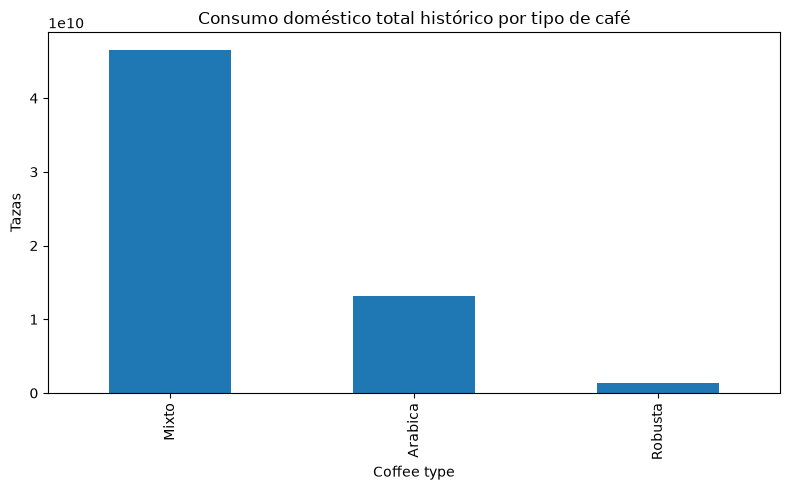

In [30]:
import matplotlib.pyplot as plt

resumen_tipo = df.groupby('Coffee type')['Total_domestic_consumption'].sum().sort_values(ascending=False)
resumen_tipo.plot(kind='bar', figsize=(8, 5), title='Consumo doméstico total histórico por tipo de café')
plt.ylabel('Tazas')
plt.tight_layout()
plt.show()

In [31]:
def forecast_lineal_con_backtest(row, year_cols, n_test=5):
    y = row[year_cols].values.astype(float)
    x = np.arange(len(y))

    x_train, y_train = x[:-n_test], y[:-n_test]
    x_test, y_test = x[-n_test:], y[-n_test:]

    coef = np.polyfit(x_train, y_train, 1)
    y_pred_test = np.polyval(coef, x_test)

    mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

    # Reentrenar con toda la serie para proyectar a futuro real
    coef_full = np.polyfit(x, y, 1)
    pred_futuro = np.polyval(coef_full, len(y) + n_test - 1)

    return mape, pred_futuro

top1_por_tipo = df.sort_values('Total_domestic_consumption', ascending=False).groupby('Coffee type').head(1)

for _, row in top1_por_tipo.iterrows():
    mape, pred = forecast_lineal_con_backtest(row, year_cols)
    print(f"{row['Country']} ({row['Coffee type']}): MAPE backtest={mape:.1f}%, "
          f"proyección +5 temporadas={pred:,.0f}")

Brazil (Mixto): MAPE backtest=4.2%, proyección +5 temporadas=1,541,925,326
Ethiopia (Arabica): MAPE backtest=5.0%, proyección +5 temporadas=263,758,465
Madagascar (Robusta): MAPE backtest=31.7%, proyección +5 temporadas=28,820,621


                             Country Coffee type  Total_domestic_consumption
2                             Brazil       Mixto                 27824700000
5                          Indonesia       Mixto                  4920480000
29                          Ethiopia     Arabica                  4536540000
41                            Mexico       Mixto                  3189660000
23                          Colombia     Arabica                  2536776384
52                         Venezuela     Arabica                  2386067999
6                         Madagascar     Robusta                   588705960
25                     Côte d'Ivoire     Robusta                   410260140
39  Lao People's Democratic Republic     Robusta                   157980000


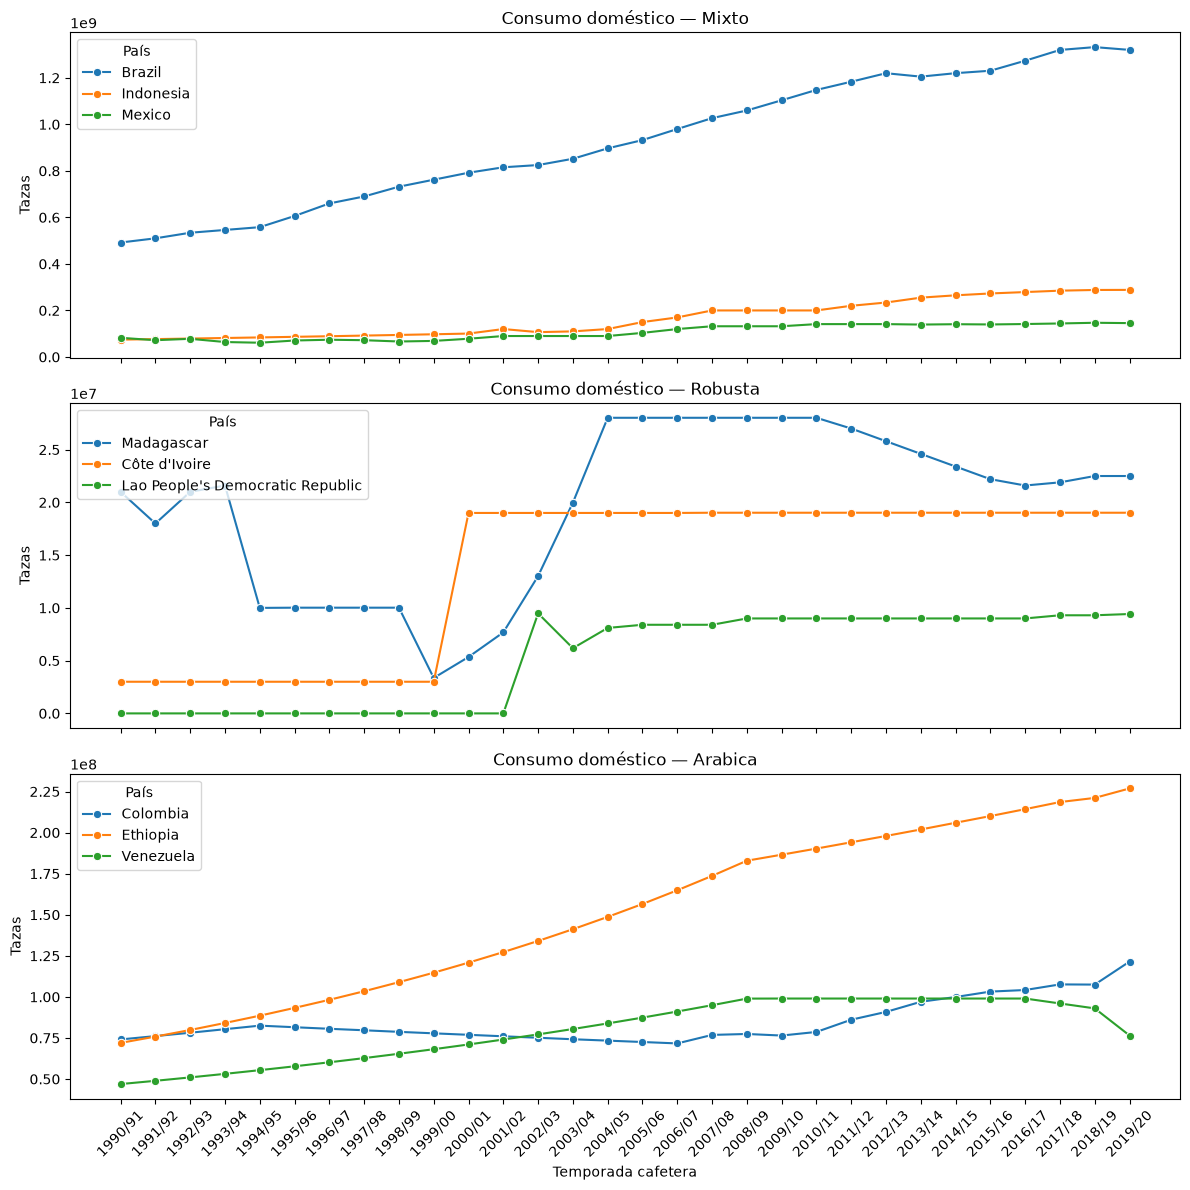

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Paso opcional: consolidar categorías mixtas ---
# Si prefieres 3 grupos limpios (Arabica, Robusta, Mixto), descomenta:
df['Coffee type'] = df['Coffee type'].replace(
    {'Robusta/Arabica': 'Mixto', 'Arabica/Robusta': 'Mixto'}
)

# --- 1. Top 3 países por tipo de café, según consumo total ---
top3_por_tipo = (
    df.sort_values('Total_domestic_consumption', ascending=False)
      .groupby('Coffee type')
      .head(3)
)

paises_seleccionados = top3_por_tipo['Country'].tolist()
print(top3_por_tipo[['Country', 'Coffee type', 'Total_domestic_consumption']])

# --- 2. Filtrar el dataset original a esos países ---
df_filtrado = df[df['Country'].isin(paises_seleccionados)]

# --- 3. Melt a formato largo, conservando Country y Coffee type ---
columnas_anio = [c for c in df.columns if '/' in c]  # detecta las columnas tipo "1990/91"

datos_largos = df_filtrado.melt(
    id_vars=['Country', 'Coffee type'],
    value_vars=columnas_anio,
    var_name='Fecha',
    value_name='Valor'
)

# --- 4. Graficar, una línea por país (usando hue) ---
tipos = datos_largos['Coffee type'].unique()
n = len(tipos)

fig, axes = plt.subplots(n, 1, figsize=(12, 4 * n), sharex=True)

# Si solo hay un tipo, axes no es una lista — normalizamos
if n == 1:
    axes = [axes]

for ax, tipo in zip(axes, tipos):
    subset = datos_largos[datos_largos['Coffee type'] == tipo]
    sns.lineplot(data=subset, x='Fecha', y='Valor', hue='Country', marker='o', ax=ax)
    ax.set_title(f'Consumo doméstico — {tipo}')
    ax.set_ylabel('Tazas')
    ax.legend(title='País', loc='upper left')

plt.xlabel('Temporada cafetera')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()